# Predicting Expert Confidence Levels in IPCC Climate Statements with LSTM Networks


**Fernando Nakamoto**


<hr style="height:2.4pt">


## Libraries

In [1]:
from IPython.display import Image, display, HTML

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [4]:
# Helper: row-normalized confusion matrix plot
def plot_confusion(y_true, y_pred, title, normalize=True):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
    cm_norm = cm.astype(float) / row_sums
    data = cm_norm if normalize else cm.astype(float)

    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    im = ax.imshow(data, cmap="Blues", vmin=0, vmax=1 if normalize else None)
    ax.set_xticks(range(4)); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(4)); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    suffix = " (row-normalized)" if normalize else ""
    ax.set_title(f"{title} - confusion matrix{suffix}")

    thresh = data.max() / 2
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}\n(n={cm[i, j]})",
                    ha="center", va="center", fontsize=9,
                    color="white" if data[i, j] > thresh else "#222222")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()


In [5]:
HTML("""
<style>

/* =========Global notebook styling====== */
body {font-family: "Inter", "Helvetica Neue", Arial, sans-serif;background-color: #fafafa;color: #2f2f2f;line-height: 1.65;}

/* =========H1 — Major Sections========== */
h1 {font-family: "Georgia", "Times New Roman", serif;font-size: 2.2em;font-weight: 600;color: #2c3e50;background: linear-gradient(90deg, #e8f0f2, #f7f9fa);padding: 16px 20px;border-radius: 12px;margin-top: 2.2em;margin-bottom: 1.2em;border-left: 8px solid #a8c3d6;}

/* =========H2 — Subsections============= */
h2 {font-family: "Georgia", "Times New Roman", serif;font-size: 1.6em;font-weight: 500;color: #34495e;margin-top: 2em;margin-bottom: 0.8em;padding-left: 14px;border-left: 4px solid #c7dce8;}

/* =========H3 — Minor headings=========== */
h3 {font-size: 1.2em;font-weight: 600;color: #4a6572;margin-top: 1.4em;margin-bottom: 0.6em;}

/* =========Paragraphs==================== */
p {font-size: 1.02em;margin-bottom: 0.9em;}

/* =========Inline math & code============ */
code {background-color: #f1f3f4;color: #37474f;padding: 2px 6px;border-radius: 6px;font-size: 0.95em;}

/* =========Math blocks=================== */
.MathJax_Display {background: #f7f9fb;padding: 14px;border-radius: 10px;border-left: 4px solid #d6e4ec;}

/* =========Lists========================= */
ul li {margin-bottom: 0.4em;}

</style>
""")


# 1. Introduction

Public discussion of climate change is increasingly flooded with statements that are false or overly alarmist. For a non-expert, it is hard to gauge how solid any given climate claim actually is: a well-established scientific finding and a speculative assertion can look linguistically similar.

This project is exploratory. Using expert judgment as ground truth, I investigate whether a neural language model can learn to assess how certain or uncertain a climate statement is, purely from its text. Concretely, I train a Long Short-Term Memory (LSTM) network to predict the confidence level that the Intergovernmental Panel on Climate Change (IPCC) scientists assigned to each of their findings.

The broader question I find interesting is whether this could be a first step toward a sustainability-oriented model that helps flag how well-established a climate claim really is. It learns to reproduce the expert-assigned confidence label of statements drawn from peer-reviewed IPCC reports. 


Objectives:

- Build an end-to-end text-classification pipeline for the ClimateX dataset.
- Compare an LSTM against simple baselines.
- Analyze how far a sequence model can go on a task where even large language models perform only slightly above chance.


# 2. Contextualization

### IPCC calibrated language: confidence vs. likelihood

The Intergovernmental Panel on Climate Change (IPCC) communicates uncertainty through a standardized calibrated language (Mastrandrea et al., 2010). It uses two distinct scales:

1. Likelihood — a probabilistic scale attached to well-quantified outcomes (e.g., virtually certain = 99–100%, very likely = 90–100%).
2. Confidence — a qualitative scale (`low`, `medium`, `high`, `very high`) that summarizes the type, amount, quality, and consistency of the evidence together with the degree of agreement among studies.

It is the confidence scale that this project targets. Each key finding in an IPCC report carries a confidence qualifier, typically in parentheses at the end of the sentence. The classification task is therefore well defined: given the statement text with the qualifier removed, recover the confidence level the authors assigned.

### The ClimateX dataset

The data comes from ClimateX (Lacombe, Wu & Dilworth, 2023), a curated, expert-labeled dataset of 8,094 natural-language statements extracted or paraphrased from the IPCC Sixth Assessment Report (AR6), covering the Working Group I (physical science), Working Group II (impacts and adaptation), and Working Group III (mitigation) reports. Each statement is annotated with its source report, page number, and the confidence level assigned by IPCC climate scientists.



# 3. Problem Definition

### Formal task

Let a statement be a sequence of tokens $x = (w_1, w_2, \dots, w_T)$. The goal is to learn a function

$$ f: x \longmapsto y, \qquad y \in \{\text{low},\ \text{medium},\ \text{high},\ \text{very high}\}, $$

that predicts the expert-assigned confidence label from the statement text alone. This is a single-label, four-class text classification problem.

### Inputs and outputs

- **Input:** one climate-science statement (a short natural-language sentence). The dataset also records the source report and page number, but these are metadata and are not used as model inputs.
- **Output:** one of four ordered confidence classes — `low` (0), `medium` (1), `high` (2), `very high` (3).

### Dataset at a glance

- 8,094 statements in total, with a predefined split: 7,794 train** / 300 test(the test set was manually reviewed and cleaned by the dataset authors).
- The classes are strongly imbalanced — `high` dominates, while `low` and `very high` are rare. 
- Statements are short-to-medium length (median ≈ 25 words).

### Evaluation

Because of the class imbalance, plain accuracy is not sufficient on its own. I report:
- Accuracy against a majority-class baseline (the honest floor), and a TF-IDF + Logistic Regression baseline.
- A per-class precision / recall / F1 report and a confusion matrix, to see whether the model recovers the minority classes or simply collapses onto `high`.

### Hardware

All experiments run locally on my laptop, a MacBook with an Apple M4 chip.


# 4. Data Loading and Exploration

The dataset is stored locally as a tab-separated file, `ipcc_statements_dataset.tsv`, in the same folder as this notebook. Each row contains the statement, its confidence label, an integer `score` (0–3) matching the label, the source `report`, and the predefined `split` (train/test).


In [6]:
# Load the dataset
DATA_PATH = "ipcc_statements_dataset.tsv"
df = pd.read_csv(DATA_PATH, sep="\t")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (8094, 8)
Columns: ['statement_idx', 'report', 'page_num', 'sent_num', 'statement', 'confidence', 'score', 'split']


,statement_idx,report,page_num,sent_num,statement,confidence,score,split
0,0,AR6_WGI,20,22,"Since 2011 (measurements reported in AR5), con...",high,2,train
1,1,AR6_WGI,21,8,Mid-latitude storm tracks have likely shifted ...,medium,1,train
2,2,AR6_WGI,21,18,The average rate of sea level rise was 1.3 [0....,high,2,train
3,3,AR6_WGI,24,2,"Since 1750, increases in CO2 (47%) and CH4 (15...",very high,3,test
4,4,AR6_WGI,24,4,Temperatures during the most recent decade (20...,medium,1,train


In [7]:
# Label encoding
label2id = {"low": 0, "medium": 1, "high": 2, "very high": 3}
id2label = {v: k for k, v in label2id.items()}
class_names = ["low", "medium", "high", "very high"]

df["label"] = df["confidence"].map(label2id)

# Predefined split
train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("Train statements:", len(train_df))
print("Test  statements:", len(test_df))


Train statements: 7794
Test  statements: 300


Train class distribution:
confidence
low           241
medium       2415
high         4611
very high     527
Name: count, dtype: int64


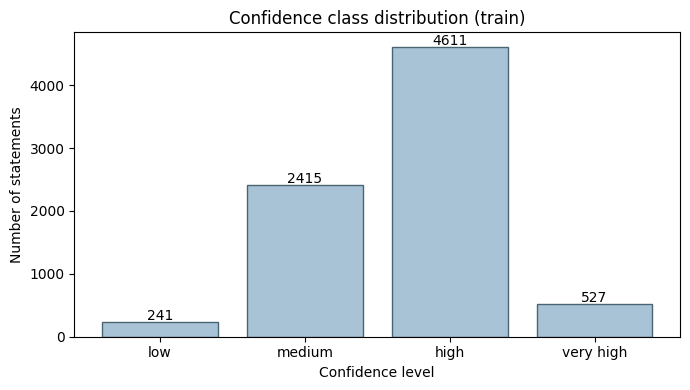

In [8]:
# Class distribution (train)
dist = train_df["confidence"].value_counts().reindex(class_names)
print("Train class distribution:")
print(dist)

plt.figure(figsize=(7, 4))
plt.bar(dist.index, dist.values, color="#a8c3d6", edgecolor="#4a6572")
plt.title("Confidence class distribution (train)")
plt.xlabel("Confidence level")
plt.ylabel("Number of statements")
for i, v in enumerate(dist.values):
    plt.text(i, v + 30, str(v), ha="center")
plt.tight_layout()
plt.show()


min       2.000000
mean     28.946626
50%      25.000000
max     579.000000
Name: n_words, dtype: float64


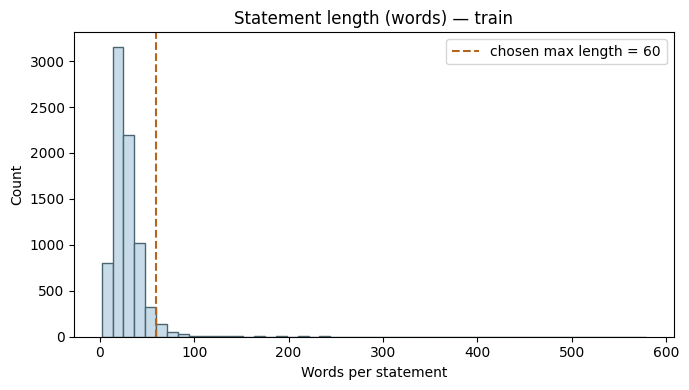

In [9]:
# Statement length distribution (in words)
train_df["n_words"] = train_df["statement"].str.split().str.len()
print(train_df["n_words"].describe()[["min", "mean", "50%", "max"]])

plt.figure(figsize=(7, 4))
plt.hist(train_df["n_words"], bins=50, color="#c7dce8", edgecolor="#4a6572")
plt.axvline(60, color="#b5651d", linestyle="--", label="chosen max length = 60")
plt.title("Statement length (words) — train")
plt.xlabel("Words per statement")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


# 5. Text Preprocessing

I convert the raw statements into padded integer sequences using a Keras `Tokenizer`:

1. Fit the tokenizer on the training statements only (to avoid leaking test vocabulary), capping the vocabulary at the 20,000 most frequent words and mapping unseen words to an `<OOV>` token.
2. Convert each statement to a sequence of word indices.
3. Pad / truncate every sequence to a fixed length of 60 tokens.

I then carve a stratified validation set out of the training data and compute class weights to counteract the imbalance during training.


In [10]:
# Tokenizer parameters
NUM_WORDS = 20000    # vocabulary cap
MAXLEN = 60          # sequence length

tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["statement"])   # fit on TRAIN only

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAXLEN, padding="post", truncating="post")

X_train_full = encode(train_df["statement"])
X_test       = encode(test_df["statement"])
y_train_full = train_df["label"].values
y_test       = test_df["label"].values

print("Vocabulary size (unique words seen):", len(tokenizer.word_index))
print("X_train_full:", X_train_full.shape, "| X_test:", X_test.shape)


Vocabulary size (unique words seen): 11324
X_train_full: (7794, 60) | X_test: (300, 60)


In [11]:
# Stratified train / validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)
print("Train:", X_tr.shape, "| Val:", X_val.shape)

# Class weights to handle imbalance
classes = np.array([0, 1, 2, 3])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)


Train: (6624, 60) | Val: (1170, 60)
Class weights: {0: 8.078048780487805, 1: 0.8070175438596491, 2: 0.42255677468742026, 3: 3.6964285714285716}


# 6. Baseline Models

I establish two baselines so that any later result can be judged fairly:

- Majority-class baseline — always predict the most frequent class (`high`).
- TF-IDF + Logistic Regression — a bag-of-words linear classifier that ignores word order. Comparing the LSTM against it answers a specific question: does the sequential structure the LSTM captures actually help on this task, or is word frequency alone just as good?


In [12]:
# Baseline 1 - majority class
majority_class = np.bincount(y_train_full).argmax()
majority_pred = np.full_like(y_test, majority_class)
majority_acc = accuracy_score(y_test, majority_pred)
print(f"Majority class = '{id2label[majority_class]}'")
print(f"Majority-class test accuracy: {majority_acc:.3f}")


Majority class = 'high'
Majority-class test accuracy: 0.333


In [13]:
# Baseline 2 - TF-IDF + Logistic Regression
tfidf = TfidfVectorizer(max_features=NUM_WORDS, ngram_range=(1, 2), sublinear_tf=True)
X_tr_tfidf = tfidf.fit_transform(train_df["statement"])
X_te_tfidf = tfidf.transform(test_df["statement"])

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_tr_tfidf, y_train_full)

logreg_pred = logreg.predict(X_te_tfidf)
logreg_acc = accuracy_score(y_test, logreg_pred)
print(f"TF-IDF + Logistic Regression test accuracy: {logreg_acc:.3f}\n")
print(classification_report(y_test, logreg_pred, target_names=class_names, zero_division=0))


TF-IDF + Logistic Regression test accuracy: 0.493

              precision    recall  f1-score   support

         low       0.50      0.22      0.31        50
      medium       0.48      0.47      0.47       100
        high       0.49      0.71      0.58       100
   very high       0.53      0.38      0.44        50

    accuracy                           0.49       300
   macro avg       0.50      0.44      0.45       300
weighted avg       0.50      0.49      0.48       300



Majority-class baseline:

              precision    recall  f1-score   support

         low       0.00      0.00      0.00        50
      medium       0.00      0.00      0.00       100
        high       0.33      1.00      0.50       100
   very high       0.00      0.00      0.00        50

    accuracy                           0.33       300
   macro avg       0.08      0.25      0.12       300
weighted avg       0.11      0.33      0.17       300



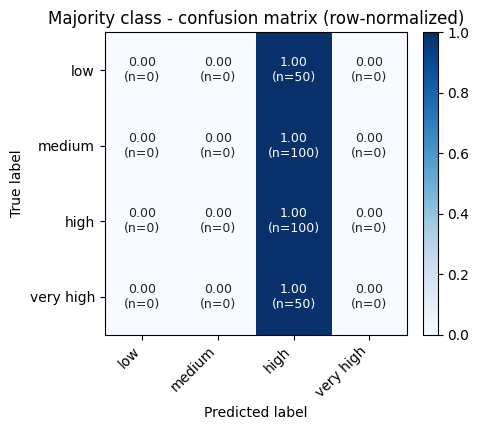

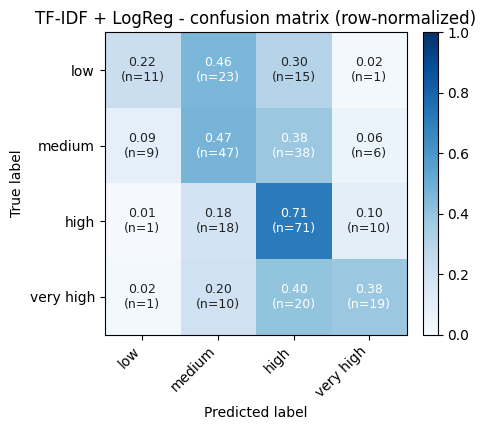

In [14]:
# Confusion matrices for the two baselines
print("Majority-class baseline:\n")
print(classification_report(y_test, majority_pred, target_names=class_names, zero_division=0))
plot_confusion(y_test, majority_pred, "Majority class")
plot_confusion(y_test, logreg_pred, "TF-IDF + LogReg")


# 7. LSTM Classifier

An `Embedding` layer that learns a dense vector for each word, an `LSTM` layer that reads the sequence and summarizes it into a single state vector, and a `Dense` softmax layer that outputs a probability over the four confidence classes. A `Dropout` layer is added for regularization, and training uses the class weights computed above.


In [21]:
EMBEDDING_DIM = 64
LSTM_UNITS = 64

def build_lstm(bidirectional=False):
    keras.backend.clear_session()
    rnn = layers.LSTM(LSTM_UNITS)
    if bidirectional:
        rnn = layers.Bidirectional(layers.LSTM(LSTM_UNITS))
    model = keras.Sequential([
        layers.Input(shape=(MAXLEN,)),
        layers.Embedding(input_dim=NUM_WORDS, output_dim=EMBEDDING_DIM, mask_zero=True),
        rnn,
        layers.Dropout(0.3),
        layers.Dense(4, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

lstm = build_lstm(bidirectional=False)
lstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,284 (5.01 MB)

 Trainable params: 1,313,284 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = lstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2138 - loss: 1.3681 - val_accuracy: 0.3821 - val_loss: 1.3391
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3354 - loss: 1.1462 - val_accuracy: 0.3915 - val_loss: 1.2117
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5389 - loss: 0.7625 - val_accuracy: 0.4051 - val_loss: 1.3644
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6901 - loss: 0.5124 - val_accuracy: 0.4538 - val_loss: 1.4193
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7568 - loss: 0.3951 - val_accuracy: 0.5308 - val_loss: 1.2777


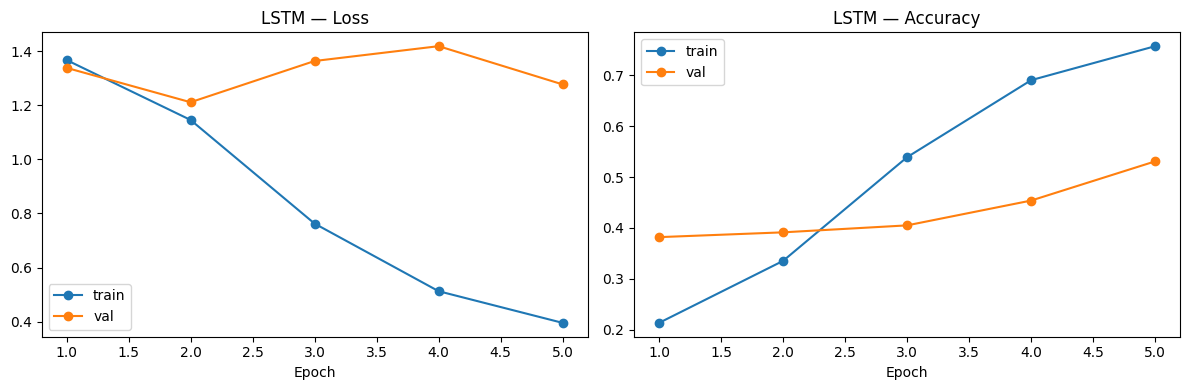

In [23]:
# Training curves
def plot_history(history, title):
    h = history.history
    epochs = range(1, len(h["loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(epochs, h["loss"], "o-", label="train")
    ax[0].plot(epochs, h["val_loss"], "o-", label="val")
    ax[0].set_title(f"{title} — Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
    ax[1].plot(epochs, h["accuracy"], "o-", label="train")
    ax[1].plot(epochs, h["val_accuracy"], "o-", label="val")
    ax[1].set_title(f"{title} — Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history, "LSTM")


# 8. Bidirectional LSTM Classifier

The unidirectional LSTM above reads each statement strictly left-to-right, so the state it produces at the final token has seen the whole sentence but every *intermediate* representation only knows about the words before it. A **bidirectional LSTM** runs two independent LSTMs — one forward, one backward — and concatenates their outputs, letting every position condition on both its left and right context. 

The architecture is otherwise identical (same embedding size, units, dropout, class weights, and early stopping), so the comparison isolates the effect of bidirectionality.

In [29]:
# Reuse the same builder with bidirectional
bilstm = build_lstm(bidirectional=True)
bilstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,346,564 (5.14 MB)

 Trainable params: 1,346,564 (5.14 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stop_bi = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_bi = bilstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop_bi],
    verbose=1,
)


Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.1301 - loss: 1.3597 - val_accuracy: 0.1684 - val_loss: 1.4156
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2773 - loss: 1.1032 - val_accuracy: 0.2385 - val_loss: 1.4068
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5071 - loss: 0.7692 - val_accuracy: 0.3350 - val_loss: 1.3597
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.6861 - loss: 0.5232 - val_accuracy: 0.4675 - val_loss: 1.1755
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7962 - loss: 0.3585 - val_accuracy: 0.5128 - val_loss: 1.3097
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8504 - loss: 0.2500 - val_accuracy: 0.4957 - val_loss: 1.4041
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8866 - loss: 0.1964 - val_accuracy: 0.5496 - val_loss: 1.3215


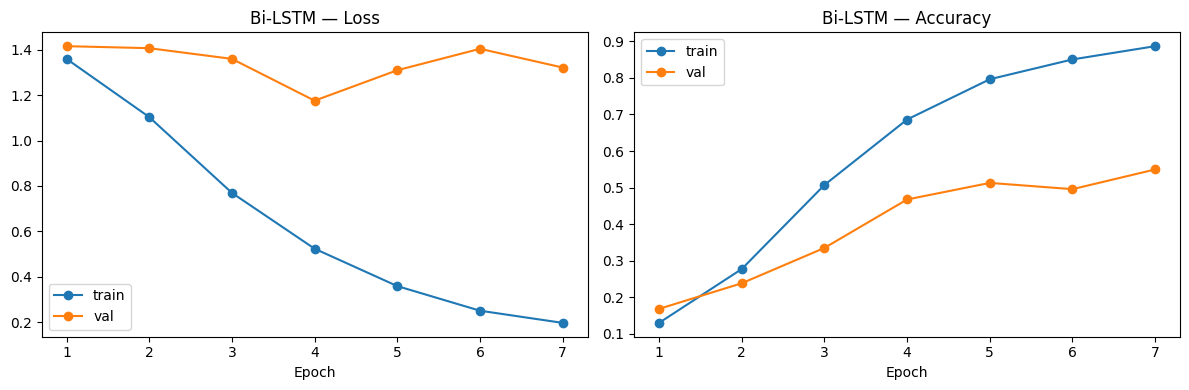

In [31]:
plot_history(history_bi, "Bi-LSTM")


# 9. Evaluation on the Test Set

Finally, I evaluate every model on the held-out 300-statement test set and compare them against the baselines. The per-class report and confusion matrix reveal whether the models actually recover the rare `low` and `very high` classes or simply default to the majority `high` class.


===== LSTM =====
Test accuracy: 0.440

              precision    recall  f1-score   support

         low       0.41      0.48      0.44        50
      medium       0.42      0.40      0.41       100
        high       0.51      0.44      0.47       100
   very high       0.40      0.48      0.44        50

    accuracy                           0.44       300
   macro avg       0.44      0.45      0.44       300
weighted avg       0.44      0.44      0.44       300



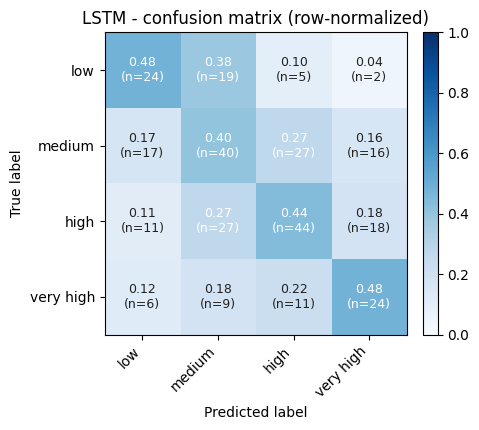

===== Bi-LSTM =====
Test accuracy: 0.473

              precision    recall  f1-score   support

         low       0.64      0.32      0.43        50
      medium       0.45      0.63      0.53       100
        high       0.52      0.48      0.50       100
   very high       0.36      0.30      0.33        50

    accuracy                           0.47       300
   macro avg       0.49      0.43      0.44       300
weighted avg       0.49      0.47      0.47       300



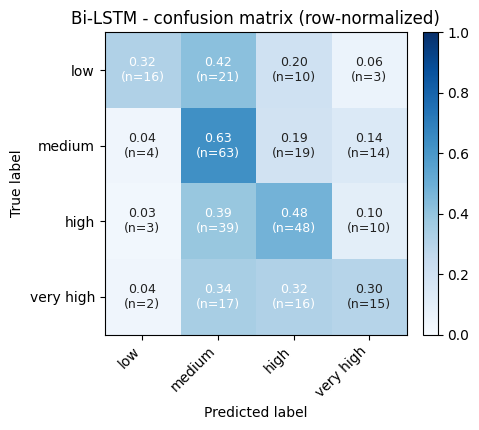

In [32]:
def evaluate(model, name):
    probs = model.predict(X_test, verbose=0)
    pred = probs.argmax(axis=1)
    acc = accuracy_score(y_test, pred)
    print(f"===== {name} =====")
    print(f"Test accuracy: {acc:.3f}\n")
    print(classification_report(y_test, pred, target_names=class_names, zero_division=0))
    plot_confusion(y_test, pred, name)
    return pred, acc

lstm_pred,   lstm_acc   = evaluate(lstm,   "LSTM")
bilstm_pred, bilstm_acc = evaluate(bilstm, "Bi-LSTM")


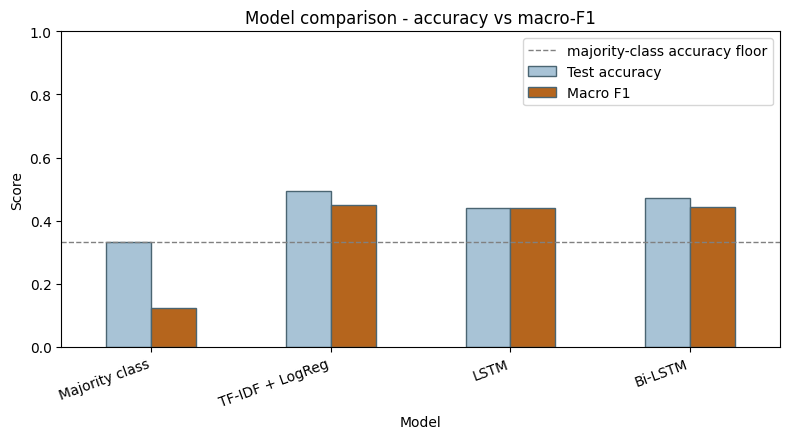

,Model,Test accuracy,Macro F1
0,Majority class,0.333,0.125
1,TF-IDF + LogReg,0.493,0.451
2,LSTM,0.440,0.440
3,Bi-LSTM,0.473,0.444


In [33]:
# Summary comparison table
def macro_f1(pred):
    return f1_score(y_test, pred, average="macro")

summary = pd.DataFrame({
    "Model": ["Majority class", "TF-IDF + LogReg", "LSTM", "Bi-LSTM"],
    "Test accuracy": [majority_acc, logreg_acc, lstm_acc, bilstm_acc],
    "Macro F1": [macro_f1(majority_pred), macro_f1(logreg_pred),
                 macro_f1(lstm_pred), macro_f1(bilstm_pred)],
})
summary["Test accuracy"] = summary["Test accuracy"].round(3)
summary["Macro F1"]      = summary["Macro F1"].round(3)

ax = summary.set_index("Model")[["Test accuracy", "Macro F1"]].plot(
    kind="bar", figsize=(8, 4.5), color=["#a8c3d6", "#b5651d"], edgecolor="#4a6572")
ax.axhline(majority_acc, color="gray", linestyle="--", linewidth=1,
           label="majority-class accuracy floor")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.set_title("Model comparison - accuracy vs macro-F1")
ax.set_xticklabels(summary["Model"], rotation=20, ha="right")
ax.legend(); plt.tight_layout(); plt.show()

summary


All three trained models clear the majority-class floor of 0.33 accuracy, but only modestly, and none of them approaches the accuracy of a competent human reader. And so we can deduce that the linguistic cues that separate one confidence level from the next are subtle and largely non-lexical. 

The single most striking result is that the TF-IDF + Logistic Regression baseline is the strongest model overall, at 0.493 accuracy and 0.451 macro-F1, ahead of both recurrent networks. Since this baseline ignores word order entirely and works from weighted unigram and bigram counts, its win answers the question I posed when setting up the baselines: on this dataset the sequential structure that the LSTM is designed to exploit does not translate into better predictions. Whatever signal exists about IPCC confidence appears to live in word choice and topic vocabulary rather than in the order in which those words are arranged, which a bag-of-words model captures at least as well as a sequence model.

Between the two recurrent models, the Bidirectional LSTM comes out ahead, at 0.473 accuracy and 0.444 macro-F1 against the plain LSTM's 0.440 on both. Reading each statement in both directions helps it lock onto the two central classes (it reaches 0.53 F1 on medium and 0.50 on high) and its macro-F1 ends up essentially level with the TF-IDF baseline, the best of any neural model here. However the plain LSTM is more evenly balanced across the four labels (its per-class F1 barely moves, from 0.41 to 0.47), so it recovers the rare low and very high classes slightly better, but it does not match the Bi-LSTM on aggregate.

The training curves temper how much weight to put on these gaps. Both networks drive training accuracy above 0.88 while validation accuracy stalls in the mid-0.50s and validation loss turns upward after a few epochs, the classic signal of overfitting on a small corpus with embeddings learned from scratch. 

# 10. Conclusion

On this task the simplest model was the most reliable: TF-IDF + Logistic Regression reached 0.493 accuracy and 0.451 macro-F1, narrowly ahead of the Bidirectional LSTM (0.473 / 0.444) and the plain LSTM (0.440 / 0.440), with every model sitting only a little above the 0.333 majority-class floor. Bidirectional context gave the Bi-LSTM a small edge over the unidirectional LSTM and pulled its macro-F1 level with the linear baseline, but neither recurrent network beat a bag-of-words classifier outright, so the sequential structure they are built to exploit bought little here, and their tendency to overfit a small, imbalanced corpus makes the margins between them unstable. 

# References

1. Lacombe, R., Wu, K., & Dilworth, E. (2023). ClimateX: Do LLMs Accurately Assess Human Expert Confidence in Climate Statements? Tackling Climate Change with Machine Learning Workshop, NeurIPS 2023. arXiv:2311.17107. https://arxiv.org/abs/2311.17107

2. ClimateX dataset. Hugging Face. https://huggingface.co/datasets/rlacombe/ClimateX  —  GitHub: https://github.com/rlacombe/ClimateX (CC-BY-4.0).

3. IPCC (2021–2022). Sixth Assessment Report (AR6) — Working Group I (The Physical Science Basis), Working Group II (Impacts, Adaptation and Vulnerability), and Working Group III (Mitigation of Climate Change). Intergovernmental Panel on Climate Change. https://www.ipcc.ch/assessment-report/ar6/

4. Mastrandrea, M. D., Field, C. B., Stocker, T. F., et al. (2010). Guidance Note for Lead Authors of the IPCC Fifth Assessment Report on Consistent Treatment of Uncertainties. Intergovernmental Panel on Climate Change.
